# DARA 40cm Photometry Data Analysis

FOR DARA KENYA SCHOOL SEP 2024

v0.0 by Xueqing Chen, and Lekshmi
Rajagopal, Fengyuan Frey Liu on 23 Sep 2024.


In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob

Before you run the notebook, make sure the notebook and data are in the same directory. You can find the data needed for this exercise at: https://drive.google.com/drive/folders/1iUGC6lwJIyJzELhAVPHLZyhEfcHe8M2w?usp=sharing

In [16]:
rawfiles = sorted(glob.glob(f'raws_bvaqr/*.fits')) # glob.glob() searches for all files in a folder that matches with the pattern "Didymos_*.fits"
rawfiles # display the file names to make sure your path is fine

['raws_bvaqr/20_03_53_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_06_57_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_09_05_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_12_18_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_15_31_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_18_49_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_21_00_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_35_57_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_41_50_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/20_48_23_Stack_16bits_19frames_61s.fits',
 'raws_bvaqr/20_59_38_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_02_57_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_07_50_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_12_06_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_14_25_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_18_57_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_29_51_Stack_16bits_38frames_61s.fits',
 'raws_bvaqr/21_32_07_Stack_16bits_38frames_61s.fits',
 'raws_bva

In [3]:
# Read the raw fits files in a loop

rawframes = [] # create an empty list to store the data frames
times = [] # create a list to store the time info from the header too

for i in range(len(rawfiles)):
    rawframes.append(fits.getdata(rawfiles[i]))
    times.append(fits.getheader(rawfiles[i])['DATE-OBS'])
    print("Frame", i)
    print(f"obs time: {fits.getheader(rawfiles[i])['DATE-OBS']}")
    print(f"exposure time: {fits.getheader(rawfiles[i])['GPS_EXPU']/1e6:.2f} s")
    print(f"filter: {fits.getheader(rawfiles[i])['FILTER']}")

rawframes = np.array(rawframes)

nframe = rawframes.shape[0] # number of frames
print('Number of frames:', nframe)
print('Shape of each frame:', (rawframes.shape[1], rawframes.shape[2]))

Frame 0
obs time: 2024-09-24T17:03:53.3967763
exposure time: 1.60 s
filter: r
Frame 1
obs time: 2024-09-24T17:07:00.7127356
exposure time: 1.60 s
filter: r
Frame 2
obs time: 2024-09-24T17:09:08.5895046
exposure time: 1.60 s
filter: r
Frame 3
obs time: 2024-09-24T17:12:22.2815559
exposure time: 1.60 s
filter: r
Frame 4
obs time: 2024-09-24T17:15:32.7438380
exposure time: 1.60 s
filter: r
Frame 5
obs time: 2024-09-24T17:18:57.6996363
exposure time: 1.60 s
filter: r
Frame 6
obs time: 2024-09-24T17:21:07.3635893
exposure time: 1.60 s
filter: r
Frame 7
obs time: 2024-09-24T17:36:05.2563827
exposure time: 1.60 s
filter: r
Frame 8
obs time: 2024-09-24T17:41:51.0189632
exposure time: 1.60 s
filter: g
Frame 9
obs time: 2024-09-24T17:49:08.4630741
exposure time: 3.20 s
filter: i
Frame 10
obs time: 2024-09-24T17:59:43.7227844
exposure time: 1.60 s
filter: r
Frame 11
obs time: 2024-09-24T18:03:03.8089613
exposure time: 1.60 s
filter: r
Frame 12
obs time: 2024-09-24T18:08:06.4396214
exposure time: 

In [4]:
# Format the observation times array
from astropy.time import Time

t = Time(times, format='isot', scale='utc', out_subfmt='date_hm') # create a Time object that makes it easy to convert the time format
mjds = t.mjd # convert to Modified Julian Date for a continuous time axis
print('mjds:', mjds)

timelabels = [] # get the time labels in the hh:mm format that we want to display
for label in t.iso:
    timelabels.append(label[-5:])
print('timelabels:', timelabels)

mjds: [60577.71103468 60577.71320269 60577.71468275 60577.71692456
 60577.71912898 60577.72150115 60577.72300189 60577.73339417
 60577.73739605 60577.74245906 60577.74981161 60577.75212742
 60577.75563009 60577.75851847 60577.76003769 60577.76322112
 60577.77077689 60577.77249974 60577.78074368 60577.78298534
 60577.78474494 60577.79045087 60577.79193291 60577.79428569
 60577.82042517 60577.82198127 60577.82472299 60577.82876157
 60577.83116986 60577.83546791 60577.8379132  60577.84111834]
timelabels: ['17:03', '17:07', '17:09', '17:12', '17:15', '17:18', '17:21', '17:36', '17:41', '17:49', '17:59', '18:03', '18:08', '18:12', '18:14', '18:19', '18:29', '18:32', '18:44', '18:47', '18:50', '18:58', '19:00', '19:03', '19:41', '19:43', '19:47', '19:53', '19:56', '20:03', '20:06', '20:11']


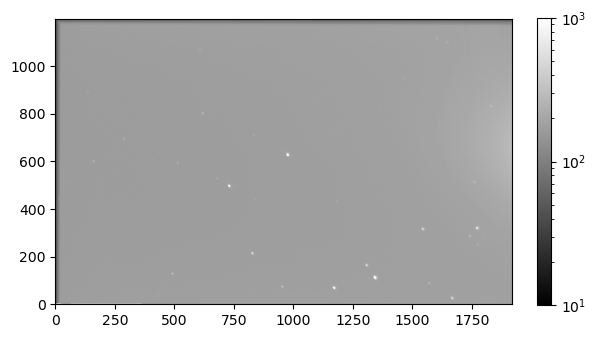

In [5]:
# Look at the first raw frame
plt.imshow(rawframes[0], cmap='gray', norm=LogNorm(vmin=10, vmax=1000), origin='lower')
plt.colorbar(fraction=0.029);

Now let's perfom the calibration:

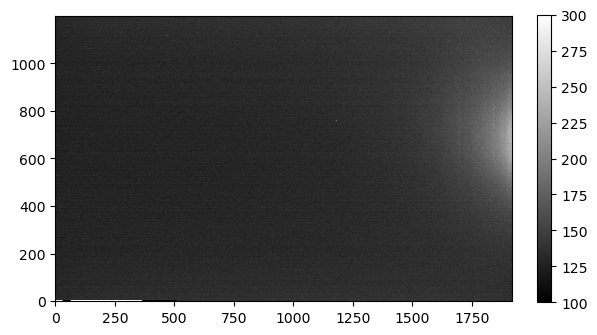

In [8]:
# Open the dark frame
dark = fits.getdata(f"masterdark_bvaqr.fits")
plt.imshow(dark, cmap='gray', vmin=100, vmax=300, origin='lower')
plt.colorbar(fraction=0.029);

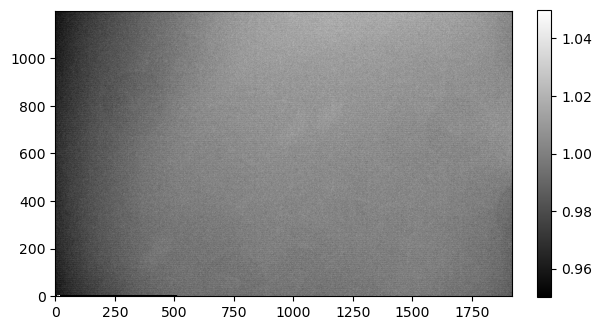

In [9]:
# Open and normalize the flat frame
flat = fits.getdata(f"masterflat_bvaqr.fits")
flat_normed = flat / np.nanmedian(flat) # normalize the flat
flat_normed[flat_normed==0] = 1e-5 # replace zeros in flat by a small number
plt.imshow(flat_normed, cmap='gray', vmin=0.95, vmax=1.05, origin='lower')
plt.colorbar(fraction=0.029);

The following cell is a concise version of the calibration demo notebook we showed earlier (https://colab.research.google.com/drive/1E9Rp5LhRq3dEloLCwSK2wodUoPJFmsrI?usp=sharing). Your data consists of a number of raw images which will each have to be reduced individually. This can be done using a loop which runs through each raw file and applies the dark and flat correction.

In [10]:
# Perfom the calibration in a loop

reducedframes = np.zeros_like(rawframes) # create an empty array to store the reduced frames

for i in range(rawframes.shape[0]):
    reducedframes[i] = (rawframes[i] - dark) / flat_normed # subtract the dark and divide by flat
    reducedframes[i][reducedframes[i]>60000] = np.median(reducedframes[i]) # replace bad pixels with median value


/tmp/ipykernel_15503/3340989754.py:6: RuntimeWarning: invalid value encountered in cast
  reducedframes[i] = (rawframes[i] - dark) / flat_normed # subtract the dark and divide by flat


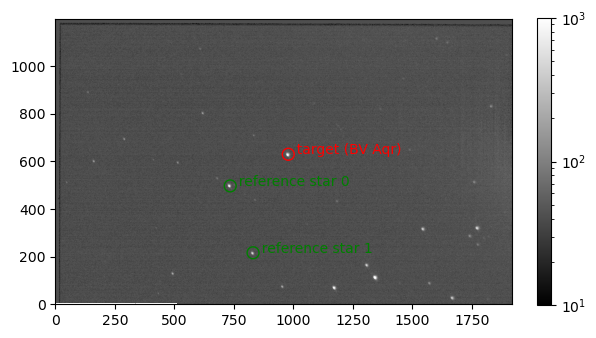

In [13]:
# Look at the first reduced frame
plt.imshow(reducedframes[0], cmap='gray', norm=LogNorm(vmin=10, vmax=1000), origin='lower')

# add a circle where the target BV Aqr is
plt.gca().add_patch(plt.Circle((979, 630), 25, fill=False, color='r'))
plt.text(979, 630 , '  target (BV Aqr)', color='r', fontsize=10)

# add a circle where the reference star is
plt.gca().add_patch(plt.Circle((735, 497), 25, fill=False, color='g'))
plt.text(735, 497 , '  reference star 0', color='g', fontsize=10)
plt.gca().add_patch(plt.Circle((831, 216), 25, fill=False, color='g'))
plt.text(831, 216, '  reference star 1', color='g', fontsize=10)

plt.colorbar(fraction=0.029);

# Analysis Part

For the data analysis, we want to perform aperture photometry on each reduced frame to measure the change in flux of the variable star BV Aqr. We also want to repeat this on some background stars as photometric references.

For this, we need to know the x and y position of the target (BV Aqr) and the reference star on each frame. To find their position, you can open all the raw fits file in DS9, using the command `ds9 *.fits` in the terminal. Move your mouse over the target / ref star to find it's position. Then, fill in the x and y coordinate you read from DS9 in the following blanks:

In [17]:
# Set the x, y coordinates of the target
xy_target = [
    (979, 630), # x, y coordinates of the target for 1st frame (only integer value is fine)
    (922,674), # fill in the x, y coordinates of the target for 2nd frame
    (883,708), # ...
    (865,710),
    (841,723),
    (818,742),
    (857,710),
    (841,682),
    (795.74, 708.992), # x, y coordinates of the target for 1st frame (only integer value is fine)
    (723.745, 762.988), # fill in the x, y coordinates of the target for 2nd frame
    (956.091, 584.638), # ...
    (915.185, 636.997),
    (859.553, 735.172),
    (826.828, 805.53),
    (805.557, 856.253),
    (733.563, 970.79),
    (984, 762), # x, y coordinates of the target for 1st frame (only integer value is fine)
    (961,822), # fill in the x, y coordinates of the target for 2nd frame
    (867,721), # ...
    (849,794),
    (792,877),
    (740,1096),
    (1029,624),
    (1031,734),
    (995, 975), # x, y coordinates of the target for 1st frame (only integer value is fine)
    (1007, 1049), # fill in the x, y coordinates of the target for 2nd frame
    (1081, 593), # ...
    (1141, 795),
    (1175, 909),
    (899, 733),
    (947, 841),
    (995, 991),
    
]

# Set the x, y coordinates of the reference star
xy_ref = [
    (735, 497), # x, y coordinates of the reference star for 1st frame
    (680,539), # ...
    (638,572),
    (625,575),
    (602,583),
    (584,598),
    (620,562),
    (620,515),
    (578.72, 535.55), # x, y coordinates of the reference star for 1st frame
    (511.034, 583.001), # ...
    (754.834, 391.561),
    (718.837, 439.012),
    (669.749, 532.278),
    (641.933, 596.091),
    (625.571, 643.542),
    (560.121, 753.17),
    (836, 539), # x, y coordinates of the reference star for 1st frame
    (807,585), # ...
    (740,471),
    (727,541),
    (677,624),
    (646,833),
    (940,362),
    (953,466),
    (1015, 695), # x, y coordinates of the reference star for 1st frame
    (1031,771), # ...
    (1119,317),
    (1193,521),
    (1235,637),
    (973,465),
    (1029,575),
    (1089,729),
]

xy_ref1 = [
    (831, 216), # x, y coordinates of another reference star for 1st frame
    (779, 257), # ...
    (740,294),
    (732,291),
    (714,299),
    (693,320),
    (740,289),
    (755,250),
    (722.109, 273.752), # x, y coordinates of another reference star for 1st frame
    (666.477, 324.475), # ...
    (926.639, 146.125),
    (893.914, 198.485),
    (853.008, 296.659),
    (835.01, 363.745),
    (818.647, 417.741 ),
    (759.743, 532.278),
    (1052, 333), # x, y coordinates of another reference star for 1st frame
    (1031,388 ), # ...
    (982,294),
    (974,375),
    (927,460),
    (906,687),
    (1203,224),
    (1221,335),
    (1313, 669), # x, y coordinates of another reference star for 1st frame
    (1329, 751), # ...
    (1417,311),
    (1491,531),
    (1533,655),
    (1271,499),
    (1325,619),
    (1381,783),
    
]

# You can also use more ref stars..
'''
xy_ref2 = [
    (555,604), # x, y coordinates of another reference star for 1st frame
    (386,661), # ...
    (388,581),
    (443,520),
    (391,650),
    (511,424),
    (714,486),
    (802,340),
    (953,145),
    (846,296)
]
'''
xy_refs = [xy_ref, xy_ref1] #, xy_ref2]

Now let's define an aperture on the target and an aperture on the ref star. Also define a ring around the apertures for estimating and subtracting the sky background.

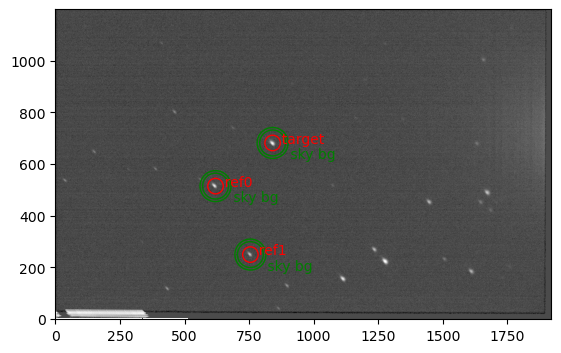

In [18]:
# Set aperture size
r_aper_target = 30 # radius of the aperture for the target star in pixels
r_aper_ref = 30    # radius of the aperture for the reference star in pixels
r_sky_inner = 50   # inner radius of the sky annulus in pixels
r_sky_outer = 60   # outer radius of the sky annulus in pixels

# Let's plot where the aperture and sky annulus are
n=7
plt.imshow(reducedframes[n], cmap='gray', origin='lower',norm=LogNorm(vmin=10, vmax=1000))
plt.gca().add_patch(plt.Circle(xy_target[n], r_aper_target, fill=False, color='r'))
plt.gca().add_patch(plt.Circle(xy_target[n], r_sky_inner, fill=False, color='g'))
plt.gca().add_patch(plt.Circle(xy_target[n], r_sky_outer, fill=False, color='g'))
plt.text(xy_target[n][0], xy_target[n][1], '  target', color='r', fontsize=10)
plt.text(xy_target[n][0], xy_target[n][1]-60, '    sky bg', color='g', fontsize=10)

for i in range(len(xy_refs)):
    plt.gca().add_patch(plt.Circle(xy_refs[i][n], r_aper_ref, fill=False, color='r'))
    plt.gca().add_patch(plt.Circle(xy_refs[i][n], r_sky_inner, fill=False, color='g'))
    plt.gca().add_patch(plt.Circle(xy_refs[i][n], r_sky_outer, fill=False, color='g'))
    plt.text(xy_refs[i][n][0], xy_refs[i][n][1], f'  ref{i}', color='r', fontsize=10)
    plt.text(xy_refs[i][n][0], xy_refs[i][n][1]-60, '    sky bg', color='g', fontsize=10);

Now we sum up the flux in each aperture and subtract it by the sky background level to get the flux of the target! Note that you need to multiple the sky background level (in counts/pixel) by the area of your aperture.

In [19]:
# Perform aperture photometry of the target

fluxes_target = [] # make a emtpy list to store the fluxes

for n in range(len(reducedframes)): # Loop over all frames
    img = reducedframes[n]

    x, y = np.meshgrid(np.arange(img.shape[1]), np.arange(img.shape[0]))
    xcen, ycen = xy_target[n]
    aper_target = ((x - xcen)**2 + (y - ycen)**2 <= r_aper_target**2) # Define the aperture as a circle
    aper_target_area = len(np.argwhere(aper_target)) # Calculate the area of the aperture

    aper_sky = ((x - xcen)**2 + (y - ycen)**2 <= r_sky_outer**2) * ((x - xcen)**2 + (y - ycen)**2 >= r_sky_inner**2) # Define the sky annulus
    aper_sky_area = len(np.argwhere(aper_sky)) # Calculate the area of the sky annulus

    flux_total = np.sum(img[aper_target]) # Calculate the total flux in the target aperture
    flux_skybg = np.median(img[aper_sky]) # Calculate the average sky background level
    flux_target = flux_total - flux_skybg * aper_target_area # Subtract the sky background from the total flux

    print('Target Frame', n)
    print(f'The area of the aperture is {aper_target_area} pixels.')
    print(f'The area of the sky annulus is {aper_sky_area} pixels.')
    print(f'The sky background level is {flux_skybg:.0f} counts/pixel.')
    print(f'The total flux in aperture is {flux_total:.0f} counts.')
    print(f'The sky counts in aperture is {flux_skybg * aper_target_area:.0f} counts.')
    print(f'The target flux after sky subtraction is {flux_target:.0f} counts.')

    fluxes_target.append(np.array(flux_target))

Target Frame 0
The area of the aperture is 2821 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 46 counts/pixel.
The total flux in aperture is 201078 counts.
The sky counts in aperture is 129766 counts.
The target flux after sky subtraction is 71312 counts.
Target Frame 1
The area of the aperture is 2821 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 45 counts/pixel.
The total flux in aperture is 196760 counts.
The sky counts in aperture is 126945 counts.
The target flux after sky subtraction is 69815 counts.
Target Frame 2
The area of the aperture is 2821 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 45 counts/pixel.
The total flux in aperture is 196564 counts.
The sky counts in aperture is 126945 counts.
The target flux after sky subtraction is 69619 counts.
Target Frame 3
The area of the aperture is 2821 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 44

Now let's repeat aperture photometry on the ref star:

In [20]:
# Perform aperture photometry of the ref star
fluxes_refs = []

for i in range(len(xy_refs)):
    fluxes_ref = []
    for n in range(len(reducedframes)):
        img = reducedframes[n]
        x, y = np.meshgrid(np.arange(img.shape[1]), np.arange(img.shape[0]))
        xcen, ycen = xy_refs[i][n]
        aper_ref =  12 # fill in this line by yourself, based on what you understand from the previous cell about the target aperture
        aper_ref_area = len(np.argwhere(aper_ref))

        aper_sky = ((x - xcen)**2 + (y - ycen)**2 <= r_sky_outer**2) * ((x - xcen)**2 + (y - ycen)**2 >= r_sky_inner**2)
        aper_sky_area = len(np.argwhere(aper_sky))

        flux_total = np.sum(img[aper_ref])
        flux_skybg = np.median(img[aper_sky])
        flux_ref = flux_total - flux_skybg * aper_ref_area

        print(f'Ref star {i} Frame', n)
        print(f'The area of the aperture is {aper_ref_area} pixels.')
        print(f'The area of the sky annulus is {aper_sky_area} pixels.')
        print(f'The sky background level is {flux_skybg:.0f} counts/pixel.')
        print(f'The total flux in aperture is {flux_total:.0f} counts.')
        print(f'The ref star flux after sky subtraction is {flux_ref:.0f} counts.')

        fluxes_ref.append(flux_ref)

    fluxes_refs.append(np.array(fluxes_ref))

fluxes_refs = np.array(fluxes_refs)

Ref star 0 Frame 0
The area of the aperture is 1 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 46 counts/pixel.
The total flux in aperture is 78061 counts.
The ref star flux after sky subtraction is 78015 counts.
Ref star 0 Frame 1
The area of the aperture is 1 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 45 counts/pixel.
The total flux in aperture is 78035 counts.
The ref star flux after sky subtraction is 77990 counts.
Ref star 0 Frame 2
The area of the aperture is 1 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 45 counts/pixel.
The total flux in aperture is 197913 counts.
The ref star flux after sky subtraction is 197868 counts.
Ref star 0 Frame 3
The area of the aperture is 1 pixels.
The area of the sky annulus is 3464 pixels.
The sky background level is 44 counts/pixel.
The total flux in aperture is 75303 counts.
The ref star flux after sky subtraction is 75259 counts.
Ref star 0

Now we have stored the target and ref star flux values of each frame. Let's plot them against the observation times to make a lightcurve!

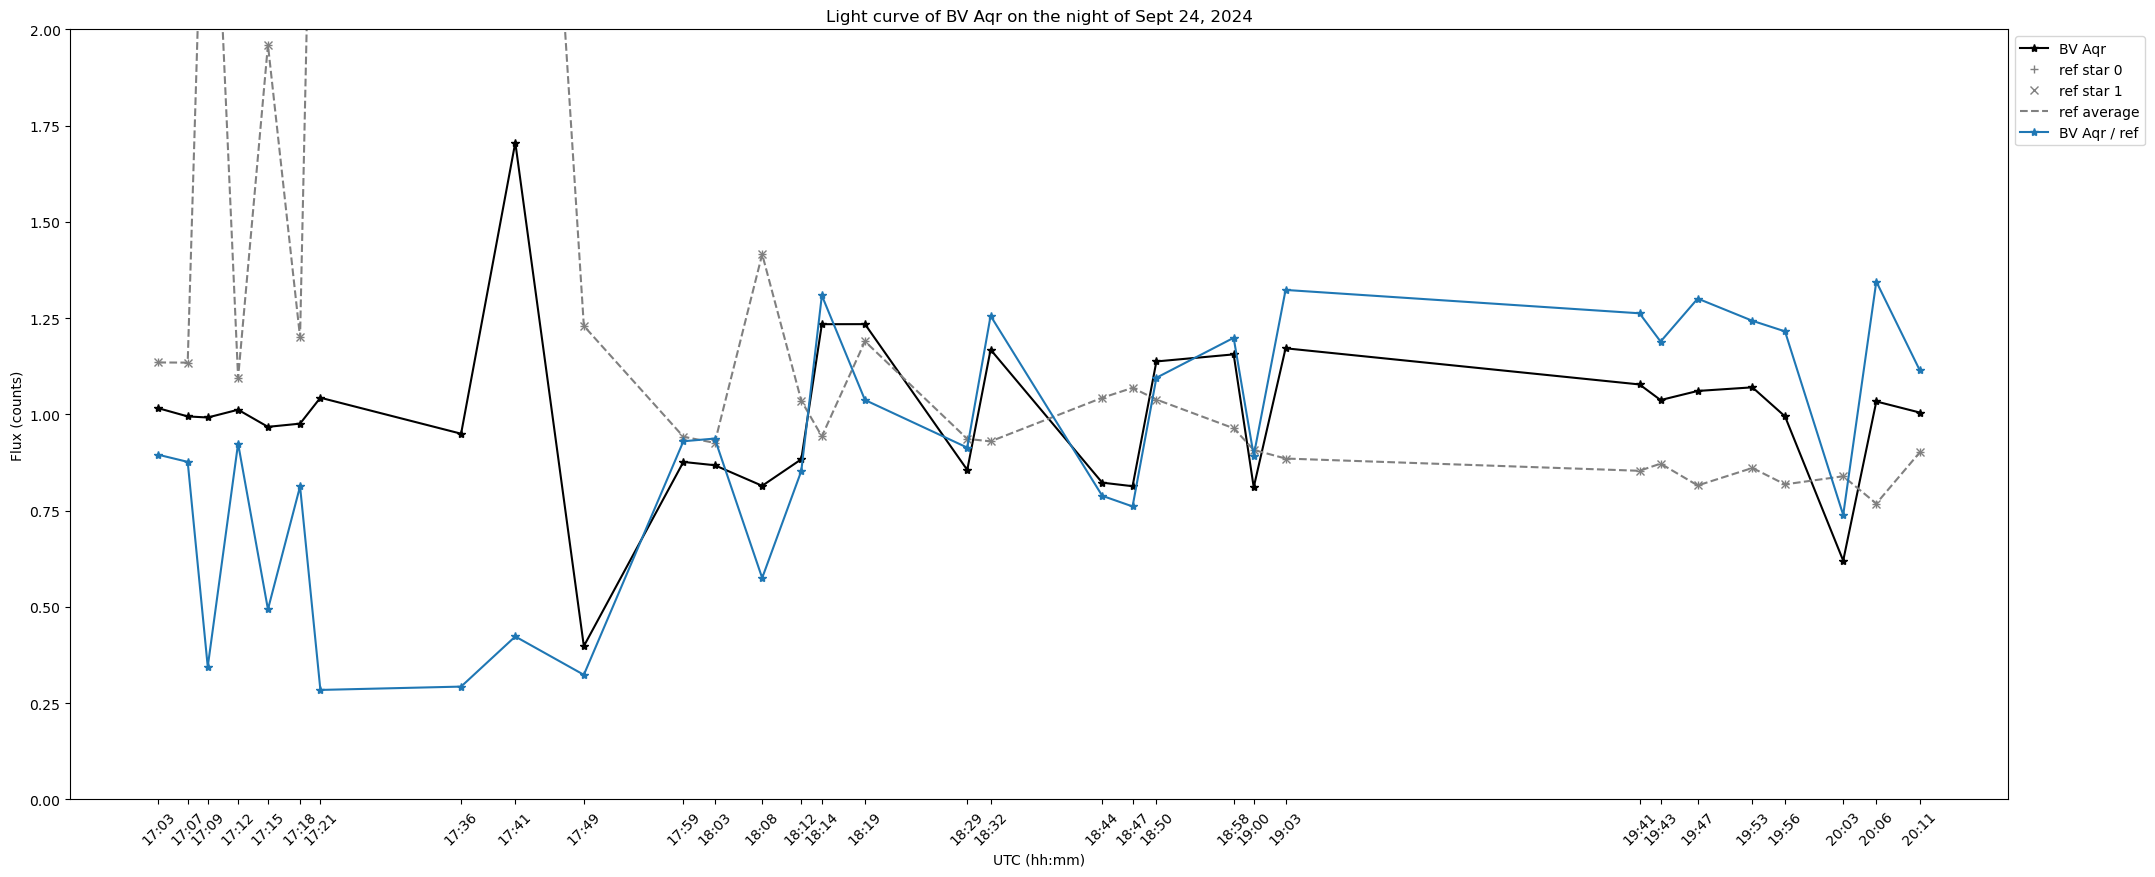

In [23]:
# Let's normalize the fluxes before we plot it, so that we can better compare the light curves
fluxes_target_norm = fluxes_target / np.median(fluxes_target)

fluxes_refs_norm = np.zeros_like(fluxes_refs) # create an empty array to store the normalized fluxes of the ref stars
for i in range(len(xy_refs)):
    fluxes_refs_norm[i] = fluxes_refs[i] / np.median(fluxes_refs[i]) # normailze each ref star's fluxes

# get the average fluxes of the reference stars
fluxes_refavg = np.median(fluxes_refs_norm, axis=0)
fluxes_refavg_norm = fluxes_refavg / np.median(fluxes_refavg)

# get the corrected target fluxes
fluxes_target_true = fluxes_target_norm / fluxes_refavg_norm

# Plot light curves of target and ref stars
plt.figure(figsize=(25, 10))
plt.plot(mjds, fluxes_target_norm, '*-', color='k', label='BV Aqr')
plt.plot(mjds, fluxes_refs_norm[0], '+', color='gray', label=f'ref star 0')
plt.plot(mjds, fluxes_refs_norm[1], 'x', color='gray', label=f'ref star 1')
plt.plot(mjds, fluxes_refavg_norm, '--', color='gray', label='ref average')
plt.plot(mjds, fluxes_target_true, '*-', label='BV Aqr / ref')
plt.ylim(0, 2)
plt.xlabel('UTC (hh:mm)')
plt.xticks(ticks=mjds, labels=timelabels, rotation=45)
plt.ylabel('Flux (counts)')
plt.title('Light curve of BV Aqr on the night of Sept 24, 2024')
plt.legend(bbox_to_anchor=(1., 1.), loc='upper left');

Now let's try to fit a sine curve to the ligth curve of BV Aqr to find out it's period!

In [24]:
from scipy.optimize import curve_fit

# define a since function
def sin_func(t, amp, w, p):
    return amp * np.sin(2*np.pi * w * t + p) + 1.

period_guess = 5./24. # guess the period to be 5 hours

guess = [
    1.,               # initial value for amp
    1./period_guess,  # initial value for w
    0,                # initial value for p
]

popt, pcov = curve_fit(sin_func, mjds, fluxes_target_true, p0=guess) # perform the fit
A, w, p = popt
err = np.sqrt(np.diag(pcov)) # get the error of the fit

print('---Fit results---')
print(f'Amplitude: {A:.2f}')
print(f'Phase: {p:.2f}')
print(f'Period: {1/w * 24.:.2f} hours')
print(f'Period error: {err[1]:.2f}')

---Fit results---
Amplitude: 0.30
Phase: -198.49
Period: 5.00 hours
Period error: 1.80


Now let's plot the fitted sine curve together with the observed light curve:

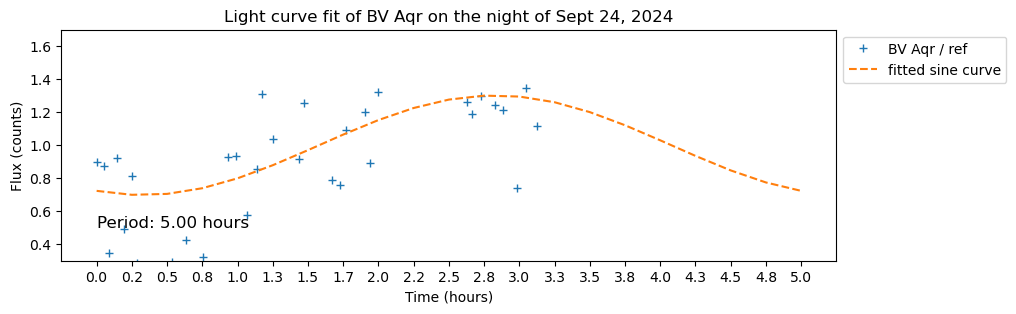

In [25]:
# Plot the fit
plt.figure(figsize=(10, 3))

plt.plot(mjds, fluxes_target_true, '+', label='BV Aqr / ref')   # plot the observed light curve of BV Aqr
x = np.linspace(mjds[0], mjds[0]+period_guess, 21)               # create an array of x values to evaluate the fitted sine function
plt.plot(x, sin_func(x, *popt), "--", label='fitted sine curve') # evaluate and plot the fitted sine curve
plt.text(x[0], 0.5, f'Period: {24. * 1/w:.2f} hours', fontsize=12)

plt.ylim(0.3, 1.7)
plt.xlabel('Time (hours)')
plt.xticks(ticks=x, labels=[f'{(i-x[0])*24.:.1f}' for i in x])
plt.ylabel('Flux (counts)')
plt.title('Light curve fit of BV Aqr on the night of Sept 24, 2024')
plt.legend(bbox_to_anchor=(1., 1.), loc='upper left');